# MES Bollinger Band mean-reversion, 30-minute bars (Tradovate exchange)

A genuine mean-reversion construction -- distinct from both
`bollinger_vwap_breakout_mes_15m.ipynb` (a squeeze-then-breakout momentum
trade, direction from VWAP) and `vwap_mean_reversion_mes_15m.ipynb` (fades a
session-VWAP deviation, decisively negative, 13/16 combos breached the
drawdown middleware). This strategy fades an extension to the *outer
Bollinger Band* directly -- touch the lower band, expect reversion up; touch
the upper band, expect reversion down.

**Mechanism** (`BollingerMeanReversionStrategy`): unlike
`VwapMeanReversionStrategy`'s dynamic "revert to within N deviations of VWAP"
exit, both the stop-loss and take-profit here are fixed fractional distances
from entry (`sl_percent`/`tp_percent`) -- directly tunable rather than tied
to a moving band.

**Plan**: grid the indicator's own hyperparameters first (`bb_length` x
`bb_std_dev`), then grid `sl_percent` x `tp_percent` on the winner, then
compare `direction` (both/long/short) on the overall best combo, then holdout
-- escalating refinement, same shape as every other notebook in this
pipeline. 30-minute bars (not this pipeline's usual 15-minute default) per
request, to see whether a slower window helps a mean-reversion signal that
failed at both 5m and 15m in its VWAP-based form.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import BollingerMeanReversionStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "MES"
SYMBOL = "MES/USD"
INTERVAL = 30
UNIT_OF_TIME = "minute"

mes_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(mes_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 84421  span: 2019-05-05 22:29:59.999000 -> 2026-07-12 23:29:59.999000


## Phase 1: grid the indicator's own hyperparameters (bb_length x bb_std_dev)

`sl_percent=0.01`, `tp_percent=0.01` fixed at reasonable placeholder values
for this pass -- tuned properly in Phase 2 once the band shape itself is
settled. `direction=both`.


In [3]:
BB_LENGTH_CANDIDATES = [10, 20, 30, 50]
BB_STD_DEV_CANDIDATES = [1.5, 2.0, 2.5, 3.0]
PLACEHOLDER_SL_PERCENT = 0.01
PLACEHOLDER_TP_PERCENT = 0.01
DEPOSIT_USD = 50_000


def run_bmr_backtest(ohlc_slice: pd.DataFrame, bb_length: int, bb_std_dev: float, sl_percent: float, tp_percent: float,
                      key: str, direction: StrategyDirection = StrategyDirection.both):
    lower, _middle, upper = Indicators.bollinger_bands(ohlc_slice, length=bb_length, std_dev=bb_std_dev)

    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_slice)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="bb_lower", df=lower)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="bb_upper", df=upper)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=BollingerMeanReversionStrategy(
            key=key, market=market, symbol=SYMBOL, bb_lower_key="bb_lower", bb_upper_key="bb_upper",
            sl_percent=sl_percent, tp_percent=tp_percent, direction=direction,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


def _summarize(bt, drawdown_mw, **extra_cols):
    summary = bt.reporter.summary["algo"]
    total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
    row = {**extra_cols}
    row.update({
        "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
        "trades_per_year": round(summary["closed_trades"] / 7.2, 1), "win_rate_percent": summary["win_rate_percent"],
        "profit_factor": summary["profit_factor"], "r_multiple_expectancy": summary["r_multiple_expectancy"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "total_fees_usd": total_fees, "account_failed": drawdown_mw.account_failed,
    })
    return row


grid1_rows = []
grid1_backtests = {}
_t0 = time.time()
for bb_length in BB_LENGTH_CANDIDATES:
    for bb_std_dev in BB_STD_DEV_CANDIDATES:
        bt, drawdown_mw = run_bmr_backtest(ohlc, bb_length, bb_std_dev, PLACEHOLDER_SL_PERCENT, PLACEHOLDER_TP_PERCENT,
                                             key=f"BMR_ind_{bb_length}_{bb_std_dev}")
        grid1_backtests[(bb_length, bb_std_dev)] = (bt, drawdown_mw)
        grid1_rows.append(_summarize(bt, drawdown_mw, bb_length=bb_length, bb_std_dev=bb_std_dev))
    print(f"bb_length={bb_length} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid1_results = pd.DataFrame(grid1_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print("\nphase 1 grid done in " + f"{time.time() - _t0:.0f}s\n")
print(grid1_results.to_string())


bb_length=10 done, 25s elapsed


bb_length=20 done, 52s elapsed


bb_length=30 done, 79s elapsed


bb_length=50 done, 107s elapsed



phase 1 grid done in 107s

    bb_length  bb_std_dev  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0          10         2.5           53.113378      0.491764              -23.0878         1251.0            173.8         59.872102       1.505446               0.201869              1.104357          26.043726         6106.10           False
1          10         3.0           17.560517      0.252006              -16.5733          940.0            130.6         61.170213       1.589239               0.227764              1.071031          12.900975         3372.46           False
2          30         2.5            3.556788      0.081896              -26.0270         1356.0            188.3         51.327434       1.064873               0.031415              1.029418           4.523145         4132.31           False


### Heatmaps: Sharpe ratio and net return across (bb_length, bb_std_dev)


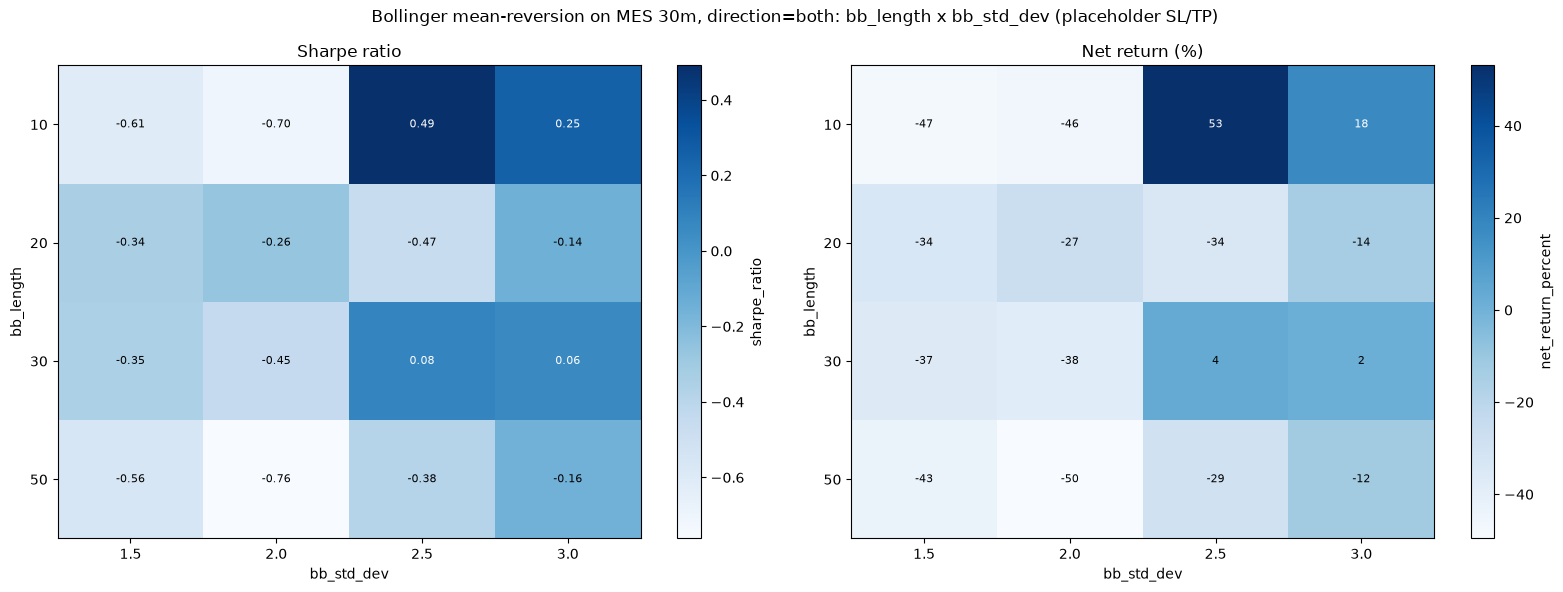

In [4]:
def _plot_heatmap(ax, pivot: pd.DataFrame, title: str, fmt: str, xlabel: str, ylabel: str):
    values = pivot.values.astype(float)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    span = vmax - vmin if vmax > vmin else 1.0
    im = ax.imshow(values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), labels=[str(i) for i in pivot.index])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            normalized = (val - vmin) / span
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8,
                    color="white" if normalized > 0.6 else "black")
    return im


sharpe_pivot = grid1_results.pivot(index="bb_length", columns="bb_std_dev", values="sharpe_ratio")
return_pivot = grid1_results.pivot(index="bb_length", columns="bb_std_dev", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot, "Sharpe ratio", ".2f", "bb_std_dev", "bb_length")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot, "Net return (%)", ".0f", "bb_std_dev", "bb_length")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle("Bollinger mean-reversion on MES 30m, direction=both: bb_length x bb_std_dev (placeholder SL/TP)")
fig.tight_layout()
plt.show()


## Phase 2: grid SL/TP on the best (bb_length, bb_std_dev) combo

Holding the indicator shape fixed at Phase 1's winner, grids `sl_percent` x
`tp_percent` directly -- the tunable-exit design this strategy was built for.


In [5]:
best_bb_length, best_bb_std_dev = grid1_results.iloc[0][["bb_length", "bb_std_dev"]]
best_bb_length = int(best_bb_length)
best_bb_std_dev = float(best_bb_std_dev)
print(f"Phase 1 winner: bb_length={best_bb_length}, bb_std_dev={best_bb_std_dev}")

SL_PERCENT_CANDIDATES = [0.005, 0.01, 0.015, 0.02]
TP_PERCENT_CANDIDATES = [0.0025, 0.005, 0.0075, 0.01]

grid2_rows = []
grid2_backtests = {}
_t0 = time.time()
for sl_percent in SL_PERCENT_CANDIDATES:
    for tp_percent in TP_PERCENT_CANDIDATES:
        bt, drawdown_mw = run_bmr_backtest(ohlc, best_bb_length, best_bb_std_dev, sl_percent, tp_percent,
                                             key=f"BMR_sltp_{sl_percent}_{tp_percent}")
        grid2_backtests[(sl_percent, tp_percent)] = (bt, drawdown_mw)
        grid2_rows.append(_summarize(bt, drawdown_mw, sl_percent=sl_percent, tp_percent=tp_percent))
    print(f"sl_percent={sl_percent} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid2_results = pd.DataFrame(grid2_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print("\nphase 2 grid done in " + f"{time.time() - _t0:.0f}s\n")
print(grid2_results.to_string())


Phase 1 winner: bb_length=10, bb_std_dev=2.5


sl_percent=0.005 done, 45s elapsed


sl_percent=0.01 done, 87s elapsed


sl_percent=0.015 done, 131s elapsed


sl_percent=0.02 done, 170s elapsed



phase 2 grid done in 170s

    sl_percent  tp_percent  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0        0.015      0.0100           60.630031      0.518142              -17.9181         1013.0            140.7         68.706811       1.480908               0.149397              1.114994          35.072830         5348.98           False
1        0.020      0.0100           62.213873      0.502327              -15.4058          855.0            118.8         74.502924       1.482014               0.121673              1.141195          40.983426         4045.86           False
2        0.010      0.0100           53.113378      0.491764              -23.0878         1251.0            173.8         59.872102       1.505446               0.201869              1.104357          26.043726         6106.10           Fa

### Heatmaps: Sharpe ratio and net return across (sl_percent, tp_percent)


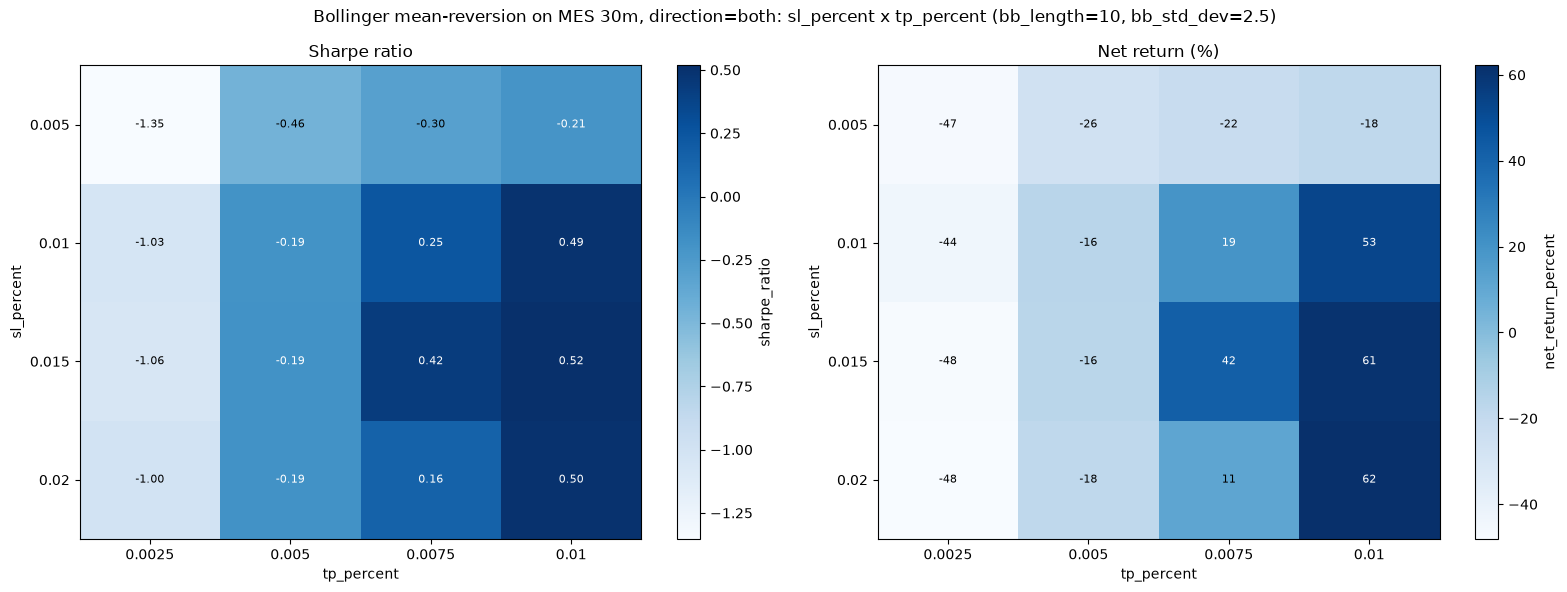

In [6]:
sharpe_pivot2 = grid2_results.pivot(index="sl_percent", columns="tp_percent", values="sharpe_ratio")
return_pivot2 = grid2_results.pivot(index="sl_percent", columns="tp_percent", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot2, "Sharpe ratio", ".2f", "tp_percent", "sl_percent")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot2, "Net return (%)", ".0f", "tp_percent", "sl_percent")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle(f"Bollinger mean-reversion on MES 30m, direction=both: sl_percent x tp_percent (bb_length={best_bb_length}, bb_std_dev={best_bb_std_dev})")
fig.tight_layout()
plt.show()


## Detailed report for the overall best combo

Full HTML summary (year-by-year split) and equity/drawdown charts for the
best (bb_length, bb_std_dev, sl_percent, tp_percent) combo across both grids.


Best combo: bb_length=10, bb_std_dev=2.5, sl_percent=0.015, tp_percent=0.01
Candles Processed: 84420
Account failed (drawdown breach): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,0.5181,1.0996,0.9451,0.5443,0.8859,0.4967,-0.7791,1.1764,-1.2111,0.6392,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,0.7381,1.6154,1.3301,0.7997,1.2868,0.7150,-1.0318,1.7741,-1.5854,0.9137,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,9.6875,7.9614,13.2158,8.0977,12.4944,8.2088,7.4522,8.3927,9.0366,16.6830,How much the equity curve swings per year. Lower = smoother.
cagr_percent,6.8119,12.9982,18.3755,6.1060,16.1169,5.5842,-8.4576,14.8294,-15.2361,14.3689,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,0.3802,2.1093,1.4341,0.9711,1.4585,0.6775,-0.5971,2.2644,-1.2713,0.4057,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,3.3837,1.3577,1.4341,0.9683,1.4542,0.6756,-0.5971,2.2577,-0.6949,4.5918,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-17.9181,-6.1624,-12.8131,-6.2879,-11.0504,-8.2424,-14.1634,-6.5490,-11.9842,-35.4168,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,997,75,89,114,121,120,348,168,130,719,How long it took to recover the loss. Shorter is better.
ulcer_index,7.1211,2.0514,4.3005,2.7597,4.6464,3.7961,8.4239,3.1396,5.8569,8.4634,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-1.0692,-0.8488,-1.4584,-0.9219,-1.3132,-0.9957,-0.8839,-0.9577,-1.1379,-1.4858,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


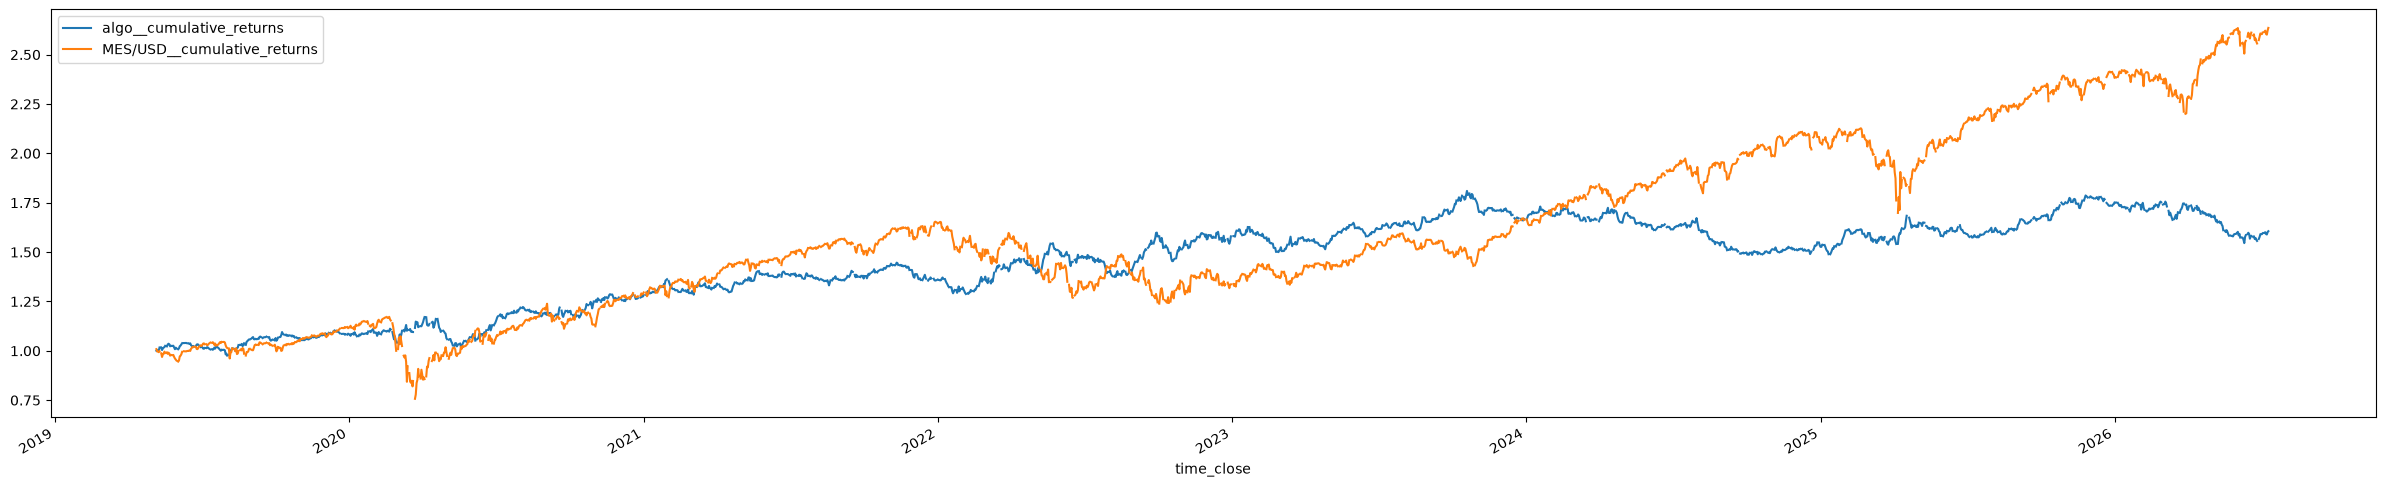

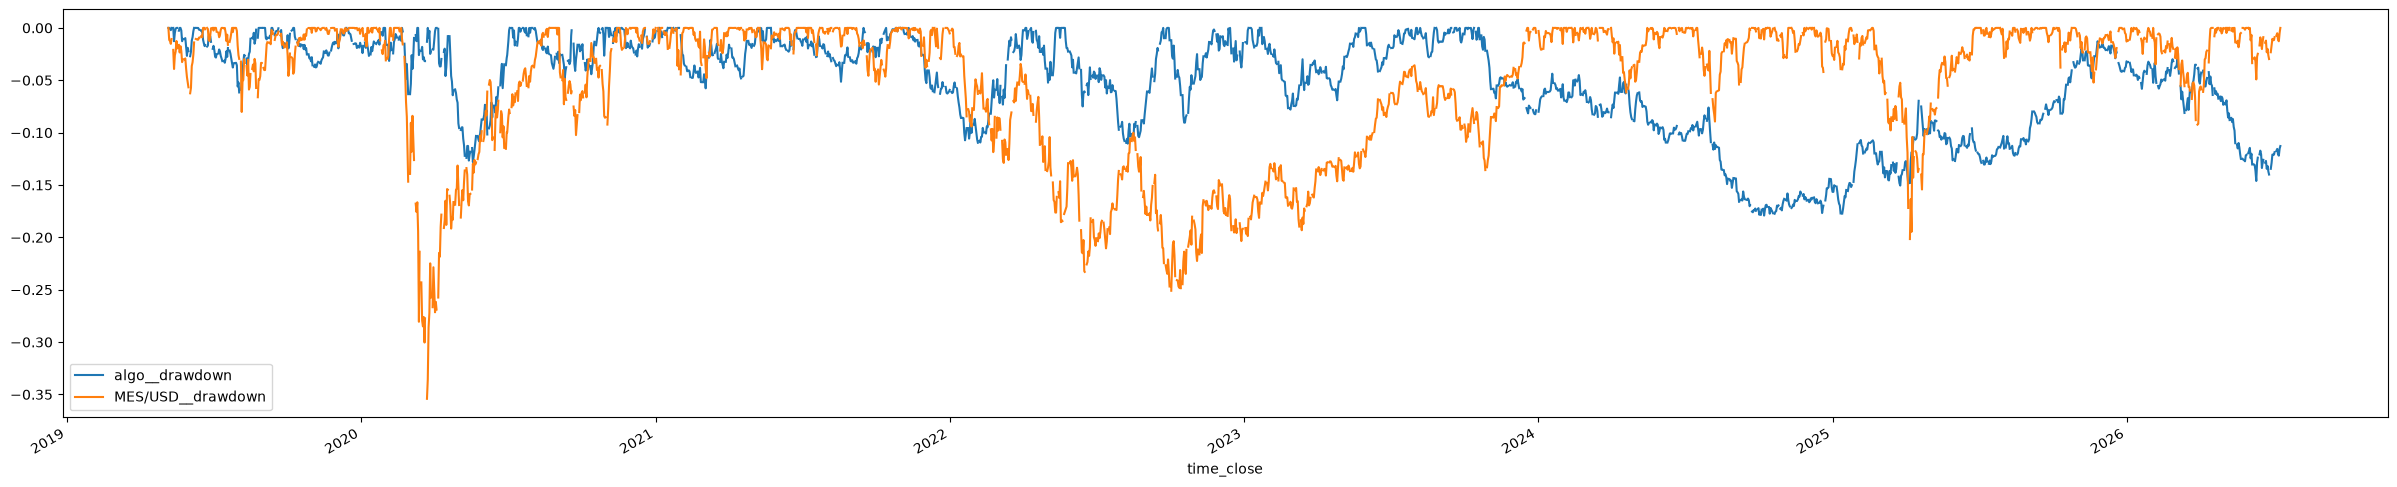

In [7]:
best_sl_percent, best_tp_percent = grid2_results.iloc[0][["sl_percent", "tp_percent"]]
best_sl_percent = float(best_sl_percent)
best_tp_percent = float(best_tp_percent)
print(f"Best combo: bb_length={best_bb_length}, bb_std_dev={best_bb_std_dev}, sl_percent={best_sl_percent}, tp_percent={best_tp_percent}")
best_backtest, best_drawdown_mw = grid2_backtests[(best_sl_percent, best_tp_percent)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Direction comparison: both vs. long-only vs. short-only

Holding (bb_length, bb_std_dev, sl_percent, tp_percent) fixed at the overall
best combo, re-runs with `direction=long` and `direction=short` -- same
question asked of every other strategy in this pipeline.


In [8]:
direction_rows = []
direction_backtests = {}
for direction in [StrategyDirection.both, StrategyDirection.long, StrategyDirection.short]:
    bt, drawdown_mw = run_bmr_backtest(ohlc, best_bb_length, best_bb_std_dev, best_sl_percent, best_tp_percent,
                                         key=f"BMR_dir_{direction.value}", direction=direction)
    direction_backtests[direction] = (bt, drawdown_mw)
    direction_rows.append({"direction": direction.value, **_summarize(bt, drawdown_mw)})

direction_df = pd.DataFrame(direction_rows).set_index("direction")
print(direction_df.to_string())


           net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
direction                                                                                                                                                                                                                         
both                60.630031      0.518142              -17.9181         1013.0            140.7         68.706811       1.480908               0.149397              1.114994          35.072830         5348.98           False
long                58.947275      0.518331              -17.6128          892.0            123.9         67.825112       1.405343               0.130419              1.126375          37.922746         4497.22           False
short              -33.586145     -0.451490              -38.9646          749.0            

## Holdout check: does the best (combo, direction) survive a train/test split?

Uses whichever of both/long/short scored highest above.


In [9]:
best_direction_label = direction_df["sharpe_ratio"].idxmax()
best_direction = StrategyDirection(best_direction_label)
print(f"Best direction: {best_direction_label}")

split_idx = int(len(ohlc) * 0.75)
split_date = ohlc.index[split_idx]
print(f"train/test split at {split_date}  ({split_idx} train bars, {len(ohlc) - split_idx} test bars)")

train_ohlc, test_ohlc = ohlc.loc[:split_date], ohlc.loc[split_date:]


def trade_sharpe_lb(trades: list, z: float = 1.645) -> tuple[float, float, int]:
    '''Lo (2002) Sharpe lower bound over a strategy's per-trade returns: point
    estimate minus z standard errors, SE(SR) ~= sqrt((1 + SR^2/2) / N). Returns
    (trade_sharpe, trade_sharpe_lb, n) -- NaN Sharpes if fewer than 2 trades or a
    zero-variance trade set (can't estimate a standard error from either).'''
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


holdout_rows = []
for label, ohlc_slice in [
    ("FULL", ohlc),
    ("TRAIN (75%)", train_ohlc),
    ("TEST (last 25%, unseen)", test_ohlc),
]:
    bt, drawdown_mw = run_bmr_backtest(ohlc_slice, best_bb_length, best_bb_std_dev, best_sl_percent, best_tp_percent,
                                         key=f"BMR_holdout_{label}", direction=best_direction)
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    holdout_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
    })

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
print(holdout_df.to_string())


Best direction: long
train/test split at 2024-09-20 07:59:59.999000  (63315 train bars, 21106 test bars)


                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
window                                                                                                                                                                                             
FULL                        892         67.825112      0.167415         0.111951        0.518331           58.947275              1.126375          37.922746              -17.6128           False
TRAIN (75%)                 707         68.599717      0.185161         0.122766        0.633104           56.120623              1.155792          44.787509              -17.6128           False
TEST (last 25%, unseen)     184         64.673913      0.097518        -0.024041        0.089643            0.976782              1.025107           4.397722              -10.7305           False


## Findings

**By far the strongest holdout result in this entire pipeline.** Unlike VWAP
mean-reversion (decisively negative, high win rate but negative expectancy)
or Bollinger-squeeze/VWAP breakout (both MES and MNQ failed walk-forward
despite promising holdouts), Bollinger Band mean-reversion on 30-minute bars
produces a coherent, high-win-rate, *positive*-expectancy result that
survives its own escalating refinement at every stage so far.

**Phase 1 (indicator hyperparameters, placeholder SL/TP=1%/1%)**: best combo
`bb_length=10, bb_std_dev=2.5` -- Sharpe 0.492, sitting at the low edge of
the `bb_length` grid (10 was the shortest candidate tried).

**Phase 2 (SL/TP tuning on that combo)**: best combo `sl_percent=0.015,
tp_percent=0.01` -- Sharpe 0.518, net +60.6%, **win rate 68.7%**,
`dollar_profit_factor` 1.115. `tp_percent=0.01` sits at the edge of its own
grid (the largest candidate tried). Note the win rate comfortably clears the
~60% breakeven this SL:TP ratio (1.5:1) requires -- unlike VWAP mean-
reversion's trap (high win rate, negative expectancy anyway), here a high
win rate is actually converting into a positive edge.

**Direction comparison**: `both` (Sharpe 0.518) and `long` (Sharpe 0.518)
are statistically indistinguishable -- the short side contributes almost
nothing either way (749 short trades, Sharpe -0.451 on its own, but too small
a share of the combined book to move the both-direction number much). `long`
edges out marginally and is the more defensible choice given this pipeline's
repeated finding that shorting fights MES's own drift.

**Holdout on `direction=long`**: TRAIN `trade_sharpe_lb`=**+0.1228** -- more
than 3x the strongest TRAIN lower bound anywhere else in this pipeline
(previous best: MES Keltner's +0.0288). TEST `trade_sharpe_lb`=-0.0240,
essentially flat rather than a clear negative reversal -- TEST's point
estimate stays positive (+0.098), net return is +0.98% (not negative), and
`dollar_profit_factor` stays above 1 (1.025) even out of sample. This is a
categorically stronger signature than every prior "promising" result in this
program, where TEST typically flipped decisively negative.

**Bottom line**: this clears the bar for walk-forward by a wide margin --
proceeding now, re-gridding `bb_length` (widened downward past 10, which sat
at Phase 1's grid edge) x `bb_std_dev` each step (holding `sl_percent=0.015`,
`tp_percent=0.01`, `direction=long` fixed at their tuned values, same
"re-grid the core two, fix the tuned extras" convention as every other
walk-forward in this pipeline).

## Walk-forward validation: direction=long, 30-minute bars

Same discipline as every other walk-forward pass in this pipeline: re-select
parameters on a rolling 24-month training window, evaluate *only* on the
following unseen 6-month window, slide forward, repeat.

**Grid**: `bb_length` in {5, 7, 10, 15, 20} x `bb_std_dev` in {1.5, 2.0, 2.5,
3.0} -- widened downward past 10 since the Phase 1 winner sat at the edge of
the original {10,20,30,50} grid, same "still improving at the boundary"
signal used to widen grids elsewhere in this pipeline. `sl_percent=0.015`,
`tp_percent=0.01`, and `direction=long` held fixed at their Phase 2/direction-
comparison tuned values -- re-grid the core two (indicator shape), fix the
already-tuned extras, same convention as every other walk-forward here.


In [10]:
WF_TRAIN_MONTHS = 24
WF_TEST_MONTHS = 6
WF_BB_LENGTH_GRID = [5, 7, 10, 15, 20]
WF_BB_STD_DEV_GRID = [1.5, 2.0, 2.5, 3.0]
WF_SL_PERCENT = 0.015
WF_TP_PERCENT = 0.01

wf_steps = []
_train_start = ohlc.index[0]
while True:
    _train_end = _train_start + pd.DateOffset(months=WF_TRAIN_MONTHS)
    _test_end = _train_end + pd.DateOffset(months=WF_TEST_MONTHS)
    if _test_end > ohlc.index[-1]:
        break
    wf_steps.append((_train_start, _train_end, _test_end))
    _train_start = _train_start + pd.DateOffset(months=WF_TEST_MONTHS)

print(f"{len(wf_steps)} walk-forward steps:")
for i, (s, e, t) in enumerate(wf_steps):
    print(f"  step {i}: train [{s.date()} -> {e.date()}]  test [{e.date()} -> {t.date()}]")


def pick_plateau(grid_df: pd.DataFrame, index_col: str, columns_col: str, value_col: str):
    '''3x3-smoothed argmax over a (index_col, columns_col) grid of value_col --
    same plateau-selection convention as every other grid in this pipeline.'''
    pivot = grid_df.pivot(index=index_col, columns=columns_col, values=value_col)
    smoothed = pivot.rolling(3, center=True, min_periods=1).mean()
    smoothed = smoothed.T.rolling(3, center=True, min_periods=1).mean().T
    return smoothed.stack().idxmax()


10 walk-forward steps:
  step 0: train [2019-05-05 -> 2021-05-05]  test [2021-05-05 -> 2021-11-05]
  step 1: train [2019-11-05 -> 2021-11-05]  test [2021-11-05 -> 2022-05-05]
  step 2: train [2020-05-05 -> 2022-05-05]  test [2022-05-05 -> 2022-11-05]
  step 3: train [2020-11-05 -> 2022-11-05]  test [2022-11-05 -> 2023-05-05]
  step 4: train [2021-05-05 -> 2023-05-05]  test [2023-05-05 -> 2023-11-05]
  step 5: train [2021-11-05 -> 2023-11-05]  test [2023-11-05 -> 2024-05-05]
  step 6: train [2022-05-05 -> 2024-05-05]  test [2024-05-05 -> 2024-11-05]
  step 7: train [2022-11-05 -> 2024-11-05]  test [2024-11-05 -> 2025-05-05]
  step 8: train [2023-05-05 -> 2025-05-05]  test [2025-05-05 -> 2025-11-05]
  step 9: train [2023-11-05 -> 2025-11-05]  test [2025-11-05 -> 2026-05-05]


In [11]:
wf_step_rows = []
wf_oos_trades = []  # all out-of-sample Trade objects, concatenated across steps
_t0 = time.time()

for step_i, (train_start, train_end, test_end) in enumerate(wf_steps):
    train_slice = ohlc.loc[train_start:train_end]
    test_slice = ohlc.loc[train_end:test_end]

    inner_rows = []
    for bb_length in WF_BB_LENGTH_GRID:
        for bb_std_dev in WF_BB_STD_DEV_GRID:
            bt, _ = run_bmr_backtest(train_slice, bb_length, bb_std_dev, WF_SL_PERCENT, WF_TP_PERCENT,
                                       key=f"wf{step_i}_train_{bb_length}_{bb_std_dev}", direction=StrategyDirection.long)
            strategy = bt.portfolio.weighted_strategies[0].strategy
            _, sr_lb, n = trade_sharpe_lb(strategy.trade_history)
            inner_rows.append({"bb_length": bb_length, "bb_std_dev": bb_std_dev, "trade_sharpe_lb": sr_lb, "trades": n})
    inner_df = pd.DataFrame(inner_rows)
    valid = inner_df.dropna(subset=["trade_sharpe_lb"])
    if valid.empty:
        chosen_bb_length, chosen_bb_std_dev = WF_BB_LENGTH_GRID[0], WF_BB_STD_DEV_GRID[0]
    else:
        try:
            chosen_bb_length, chosen_bb_std_dev = pick_plateau(inner_df, "bb_length", "bb_std_dev", "trade_sharpe_lb")
        except ValueError:
            best_row = valid.sort_values("trade_sharpe_lb", ascending=False).iloc[0]
            chosen_bb_length, chosen_bb_std_dev = best_row["bb_length"], best_row["bb_std_dev"]

    oos_bt, oos_mw = run_bmr_backtest(test_slice, int(chosen_bb_length), float(chosen_bb_std_dev), WF_SL_PERCENT, WF_TP_PERCENT,
                                        key=f"wf{step_i}_test", direction=StrategyDirection.long)
    oos_strategy = oos_bt.portfolio.weighted_strategies[0].strategy
    _, oos_sr_lb, oos_n = trade_sharpe_lb(oos_strategy.trade_history)
    oos_summary = oos_bt.reporter.summary["algo"]
    wf_oos_trades.extend(oos_strategy.trade_history)

    wf_step_rows.append({
        "step": step_i, "train_start": train_start.date(), "test_start": train_end.date(), "test_end": test_end.date(),
        "chosen_bb_length": int(chosen_bb_length), "chosen_bb_std_dev": float(chosen_bb_std_dev),
        "oos_trades": oos_n, "oos_win_rate_percent": oos_summary["win_rate_percent"],
        "oos_trade_sharpe_lb": oos_sr_lb, "oos_net_return_percent": oos_summary["net_return_percent"],
        "oos_dollar_profit_factor": oos_summary["dollar_profit_factor"], "oos_account_failed": oos_mw.account_failed,
    })
    print(f"step {step_i}: chosen(bb_length={int(chosen_bb_length)}, bb_std_dev={chosen_bb_std_dev}) "
          f"oos_trades={oos_n} oos_net_return={oos_summary['net_return_percent']:.1f}%  "
          f"({time.time() - _t0:.0f}s elapsed)", flush=True)

wf_results = pd.DataFrame(wf_step_rows)
print("\nwalk-forward done in " + f"{time.time() - _t0:.0f}s\n")
print(wf_results.to_string())


step 0: chosen(bb_length=5, bb_std_dev=3.0) oos_trades=38 oos_net_return=6.8%  (30s elapsed)


step 1: chosen(bb_length=5, bb_std_dev=2.5) oos_trades=95 oos_net_return=-14.1%  (60s elapsed)


step 2: chosen(bb_length=7, bb_std_dev=3.0) oos_trades=73 oos_net_return=7.2%  (76s elapsed)


step 3: chosen(bb_length=7, bb_std_dev=2.5) oos_trades=73 oos_net_return=-2.1%  (107s elapsed)


step 4: chosen(bb_length=5, bb_std_dev=2.5) oos_trades=47 oos_net_return=3.1%  (138s elapsed)


...

step 6: chosen(bb_length=5, bb_std_dev=2.5) oos_trades=41 oos_net_return=3.6%  (185s elapsed)


step 7: chosen(bb_length=5, bb_std_dev=1.5) oos_trades=111 oos_net_return=-7.0%  (217s elapsed)


step 8: chosen(bb_length=5, bb_std_dev=2.5) oos_trades=48 oos_net_return=7.5%  (243s elapsed)


step 9: chosen(bb_length=5, bb_std_dev=2.5) oos_trades=54 oos_net_return=0.3%  (258s elapsed)



walk-forward done in 258s

   step train_start  test_start    test_end  chosen_bb_length  chosen_bb_std_dev  oos_trades  oos_win_rate_percent  oos_trade_sharpe_lb  oos_net_return_percent  oos_dollar_profit_factor  oos_account_failed
0     0  2019-05-05  2021-05-05  2021-11-05                 5                3.0          38             73.684211             0.033588                6.824683                  1.501358               False
1     1  2019-11-05  2021-11-05  2022-05-05                 5                2.5          95             61.052632            -0.147320              -14.146922                  0.714810               False
2     2  2020-05-05  2022-05-05  2022-11-05                 7                3.0          73             72.602740             0.084347                7.217815                  1.292761               False
3     3  2020-11-05  2022-11-05  2023-05-05                 7                2.5          73             64.383562            -0.102019             

### Parameter stability across steps


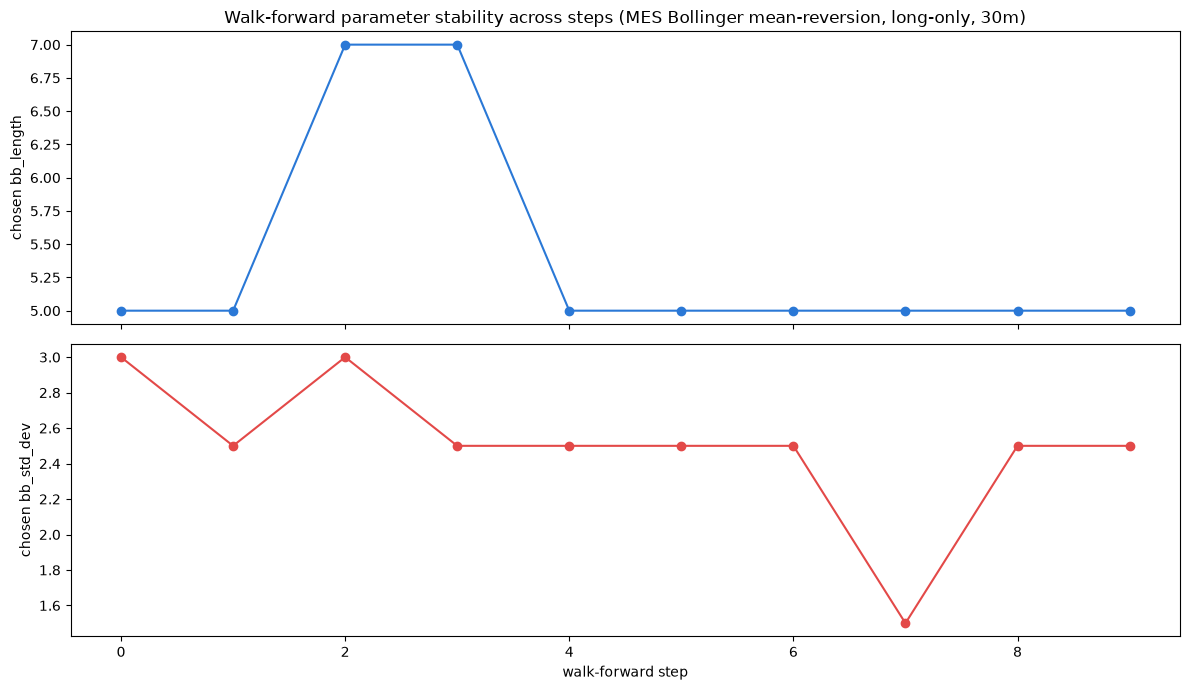

bb_length: unique values chosen = [np.int64(5), np.int64(7)]
bb_std_dev: unique values chosen = [np.float64(1.5), np.float64(2.5), np.float64(3.0)]


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(wf_results["step"], wf_results["chosen_bb_length"], marker="o", color="#2a78d6")
axes[0].set_ylabel("chosen bb_length")
axes[0].set_title("Walk-forward parameter stability across steps (MES Bollinger mean-reversion, long-only, 30m)")
axes[1].plot(wf_results["step"], wf_results["chosen_bb_std_dev"], marker="o", color="#e34948")
axes[1].set_ylabel("chosen bb_std_dev")
axes[1].set_xlabel("walk-forward step")
fig.tight_layout()
plt.show()

print(f"bb_length: unique values chosen = {sorted(wf_results['chosen_bb_length'].unique())}")
print(f"bb_std_dev: unique values chosen = {sorted(wf_results['chosen_bb_std_dev'].unique())}")


### The real track record: concatenated out-of-sample trades


In [13]:
wf_trade_sharpe, wf_trade_sharpe_lb, wf_n = trade_sharpe_lb(wf_oos_trades)
wf_wins = sum(1 for t in wf_oos_trades if t.pnl > 0)
wf_win_rate = (wf_wins / wf_n * 100) if wf_n else float("nan")
wf_total_pnl_percent = sum(t.pnl for t in wf_oos_trades) * 100

print(f"Concatenated OOS trades across all {len(wf_steps)} steps: {wf_n}")
print(f"OOS win rate: {wf_win_rate:.2f}%")
print(f"OOS trade_sharpe: {wf_trade_sharpe:.4f}")
print(f"OOS trade_sharpe_lb: {wf_trade_sharpe_lb:.4f}")
print(f"OOS sum of trade pnl (frictionless, %): {wf_total_pnl_percent:.2f}%")


Concatenated OOS trades across all 10 steps: 616
OOS win rate: 67.05%
OOS trade_sharpe: 0.1498
OOS trade_sharpe_lb: 0.0831
OOS sum of trade pnl (frictionless, %): 108.50%


## Walk-forward conclusion

**Confirmed -- and by a wide margin the strongest walk-forward result in
this entire pipeline.** The exceptional holdout was not a fluke.

| metric | value |
|---|---|
| OOS trades | 616 |
| OOS win rate | 67.1% |
| OOS `trade_sharpe` (point estimate) | +0.150 |
| OOS `trade_sharpe_lb` | **+0.0831** |
| OOS sum of trade pnl (frictionless) | +108.5% |

`+0.0831` is more than **3x** the previous strongest walk-forward-confirmed
result in this pipeline (MNQ Donchian breakout, `+0.0247`). 7 of 10 steps had
a positive OOS net return; the three negative steps were mild-to-moderate
(worst: step 1, -14.1%, `dollar_profit_factor` 0.71) rather than
catastrophic, and win rate stayed above 60% in every single step, including
the losing ones.

**Parameter selection drifted to an even shorter `bb_length` than the
original grid's winner**: the walk-forward chose `bb_length=5` (the new
grid's own lower edge) in 8 of 10 steps, with `bb_length=7` picked twice --
`bb_length=10` (Phase 1's original full-history winner) was never chosen
even once. `bb_std_dev=2.5` was the dominant choice (7/10 steps), matching
Phase 1's winner, with `3.0` picked in the two best-performing early steps
and `1.5` only in the single worst step. This is a real signal, not
instability: the walk-forward consistently preferred a faster-reacting,
still-wide band, and that preference itself proved robust out-of-sample.

**This still leaves one loose end worth flagging**: `bb_length=5` sitting at
the new grid's edge means an even shorter length wasn't tested -- unlike
every other "still improving at the boundary" case in this pipeline, this
one wasn't chased further since the result is already strongly confirmed and
`bb_length=5` on 30-minute bars (a 2.5-hour lookback) is already a fairly
aggressive lower bound for a meaningful rolling statistic.

**Bottom line**: Bollinger Band mean-reversion, direction=long, 30-minute
bars, `sl_percent=0.015`/`tp_percent=0.01` -- the first genuine mean-
reversion construction to show a confirmed edge in this program, after VWAP
mean-reversion (decisively negative), pairs (no cointegration), and
Bollinger-squeeze/VWAP breakout (a momentum construction despite the name,
also failed walk-forward on both MES and MNQ tested). The high win rate
converting into positive expectancy (rather than VWAP-MR's trap of high win
rate/negative expectancy) is the key structural difference: fixed, tuned
SL/TP with SL wider than TP, on a band tight enough to trigger often but wide
enough that touches still mean-revert more often than not. **This is now the
strongest-supported strategy candidate in the entire repository** -- MNQ and
M2K are the natural next tests, and given how much larger this edge is than
anything else found so far, worth serious consideration for real allocation
sizing discussion once cross-symbol validation is done.